# Make the stacked histogram of the MORDOR survey white dwarfs binned by Teff.

Probably need to import the usual suspects of modules first to get things going.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
#import scipy.interpolate as scinterp
import time

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

In [2]:
import spec_plot_tools as spt
import cal_params as cp

Need to read in the overall file for the data, and need that directory that it comes from.

In [3]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
output_path='/Users/BenKaiser/Desktop/'

In [4]:
input_file='full_MORDOR_survey_1681141339_fullphotometry_fitparams.csv'

In [5]:
input_table= Table.read(input_path+input_file)

In [6]:
input_table.pprint()

       name       ...
----------------- ...
MORDOR J0008-2404 ...
  SDSS J0049+2244 ...
MORDOR J0110-5926 ...
MORDOR J0110-5600 ...
MORDOR J0126-4707 ...
  SDSS J0132+1823 ...
MORDOR J0135-6306 ...
       LEHPM 1774 ...
  LSPM J0211+0835 ...
MORDOR J0225-3312 ...
              ... ...
MORDOR J2126-7502 ...
MORDOR J2158+4243 ...
MORDOR J2236-3635 ...
MORDOR J2238-5558 ...
MORDOR J2244+4204 ...
  SDSS J2309+0959 ...
  SDSS J2314+2717 ...
MORDOR J2320-6637 ...
MORDOR J2324-5942 ...
MORDOR J2339+3728 ...
     WD J2356-209 ...
Length = 120 rows


In [7]:
for col in input_table.colnames:
    print(col)

name
designation
dr2_source_id
gf19
pwd
f_pwd
sp_type
sed_sp_type
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitud

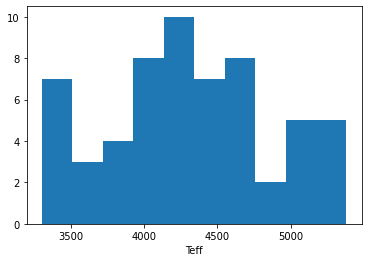

In [8]:
plt.hist(input_table['teff'])
plt.xlabel('Teff')
plt.show()

In [9]:
print(np.nanmin(input_table['teff']),np.nanmax(input_table['teff']))

3303 5380


In [10]:
dc_array=input_table['teff'][np.where(input_table['sp_type']=='DC')]
dq_array=input_table['teff'][np.where(input_table['sp_type']=='DQpec')]
dz_array=input_table['teff'][np.where(input_table['sp_type']=='DZ')]

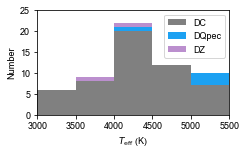

1744208373.984519


In [11]:
fig=spt.start_mnras_fig(width_cols=1)
plt.hist([dc_array,dq_array,dz_array],bins=np.arange(3000,6000,500),stacked=True,color=[cp.sp_type_colors['DC'],cp.sp_type_colors['DQpec'],cp.sp_type_colors['DZ']],label=['DC','DQpec','DZ'])
plt.xlabel(r'$T_{\rm{eff}}$ (K)')
plt.ylabel('Number')
plt.xlim(3000,5500)
plt.ylim(0,25)
plt.legend()
plt.show()

start = time.time()
print(start)
time_string=str(start).split('.')[0]
#plt.savefig(output_path+"spec_type_teff_hist_stacked_"+time_string+'.pdf')#plt.grid(True)


In [12]:
mean_teff= np.nanmean(input_table['teff'])
std_teff=np.std(input_table['teff'])
print(mean_teff,'+/-',std_teff)

4316.8983050847455 +/- 549.7532172053527


In [13]:
mean_teff= np.nanmean(dc_array)
std_teff=np.std(dc_array)
print(mean_teff,'+/-',std_teff)

4278.264150943396 +/- 530.4104196215861


### I need to make sure these bars are the same colors as the scatter plot colors

On which point, I need to change the DZs to not be pink anymore. They look too much like the WD+dM points on many printers.